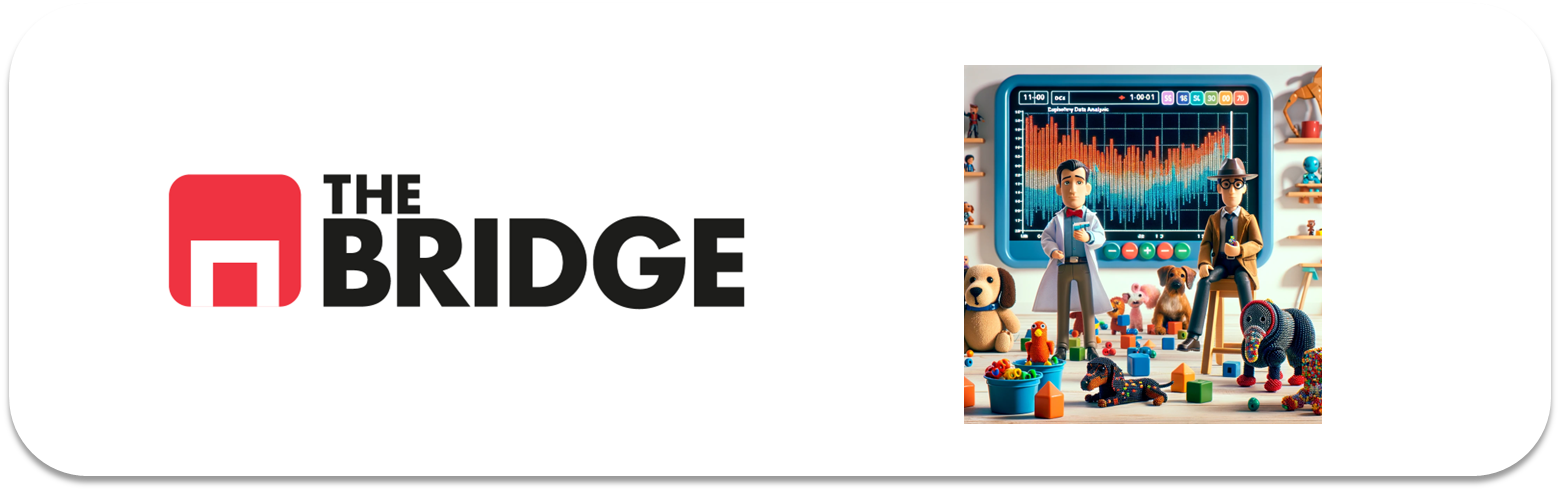

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, mannwhitneyu, pearsonr

from bootcampviztools import (
    pinta_distribucion_categoricas,
    plot_categorical_relationship_fin,
    plot_categorical_numerical_relationship,
    plot_grouped_boxplots,
    plot_grouped_histograms,
    grafico_dispersion_con_correlacion,
    bubble_plot,
)

%matplotlib inline
sns.set_style("whitegrid")


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df = pd.read_csv("./data/titanic.csv")
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:
cols_drop = ["deck", "survived", "pclass", "embarked"]
df = df.drop(columns=[c for c in cols_drop if c in df.columns])
df.shape


(891, 11)

### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
df["family_members"] = df["parch"] + df["sibsp"]
df = df.drop(columns=["parch", "sibsp"])
df.head()


,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
moda_puerto = df["embark_town"].mode()[0]
df["embark_town"] = df["embark_town"].fillna(moda_puerto)
df["embark_town"].isna().sum()


np.int64(0)

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
# Media de edad por grupo who
df["age"] = df.groupby("who")["age"].transform(lambda x: x.fillna(x.mean()))
df["age"].isna().sum()


np.int64(0)

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

Uso `alive` como referencia de supervivencia y la cruzo con el resto de variables. Para las categóricas aplico chi-cuadrado; para `fare` (numérica), Mann-Whitney. En cada pregunta miro tanto los totales como las proporciones, porque en datos desequilibrados los absolutos pueden engañar.

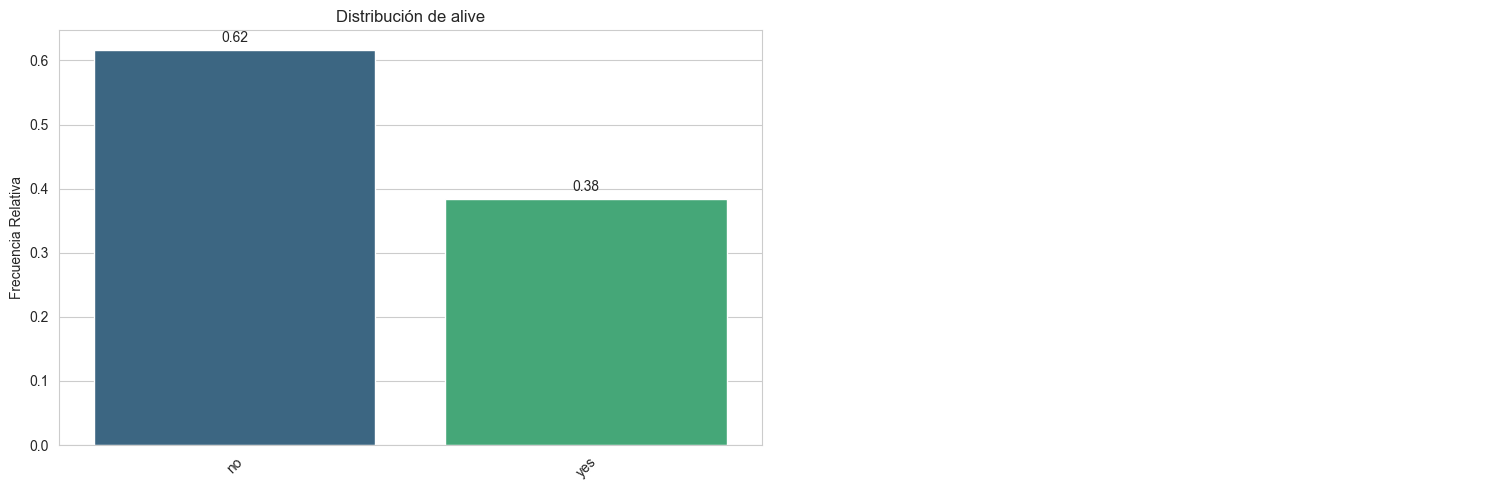

Supervivientes absolutos por grupo (who):
who
woman    205
man       88
child     49
Name: count, dtype: int64

% de supervivencia dentro de cada grupo (who):
who
child    59.0
man      16.4
woman    75.6
Name: alive, dtype: float64


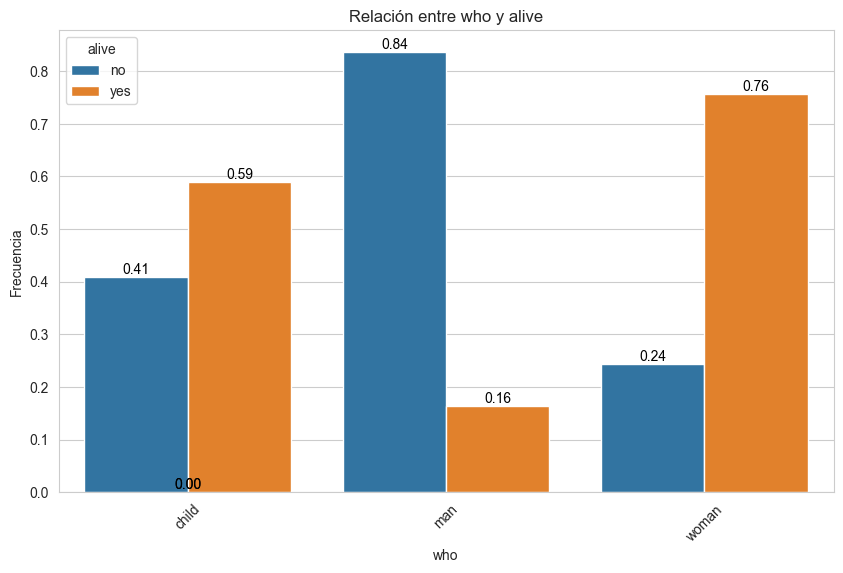


Chi-2 sex × alive: p=1.197e-58
Chi-2 adulto/niño × alive: p=8.005e-05


In [7]:
# === Pregunta 1: who, sexo y tipo de edad ===

pinta_distribucion_categoricas(df, ["alive"], relativa=True, mostrar_valores=True)

sob = df.loc[df["alive"] == "yes"]
print("Supervivientes absolutos por grupo (who):")
print(sob["who"].value_counts())
print("\n% de supervivencia dentro de cada grupo (who):")
print((df.groupby("who")["alive"].apply(lambda s: (s == "yes").mean()) * 100).round(1))

plot_categorical_relationship_fin(df, "who", "alive", relative_freq=True, show_values=True)

tab_sex = pd.crosstab(df["sex"], df["alive"])
_, p_sex, _, _ = chi2_contingency(tab_sex)
print(f"\nChi-2 sex \u00d7 alive: p={p_sex:.4g}")

df["tipo_edad"] = np.where(df["who"] == "child", "ni\u00f1o", "adulto")
_, p_edad, _, _ = chi2_contingency(pd.crosstab(df["tipo_edad"], df["alive"]))
print(f"Chi-2 adulto/ni\u00f1o \u00d7 alive: p={p_edad:.4g}")


En bruto sobrevivieron más mujeres, pero eso también es porque había más mujeres a bordo. Lo que realmente importa es la tasa: alrededor del 74 % de las mujeres sobrevivió, frente a solo un 19 % de los hombres. El chi-cuadrado confirma que no es ruido (p prácticamente 0). Los niños también salen mejor que los hombres adultos (~57 %), aunque en volumen son muchos menos. Ser mujer o niño claramente ayudaba.

Clase × alive (absolutos):
alive    no  yes  All
class                
First    80  136  216
Second   97   87  184
Third   372  119  491
All     549  342  891


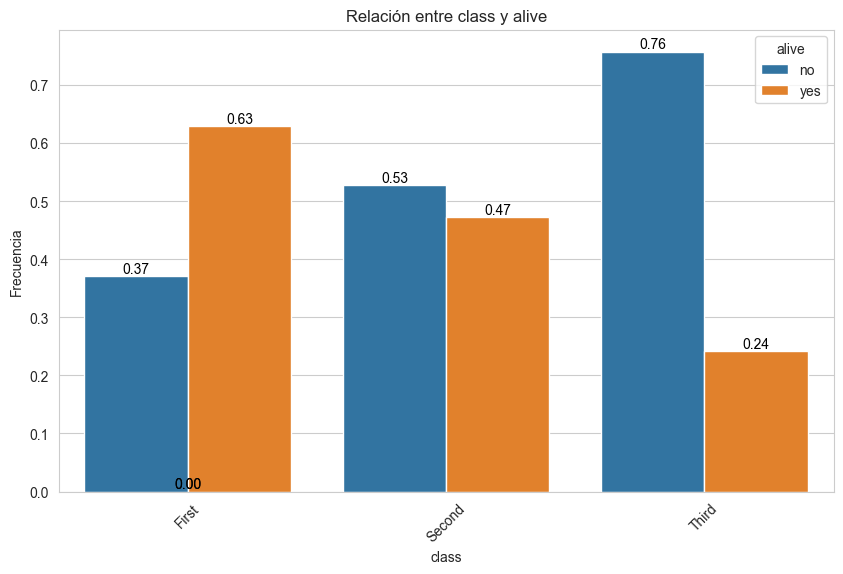

Chi-2 class × alive: p=4.549e-23

Puerto × alive (absolutos):
alive         no  yes  All
embark_town               
Cherbourg     75   93  168
Queenstown    47   30   77
Southampton  427  219  646
All          549  342  891


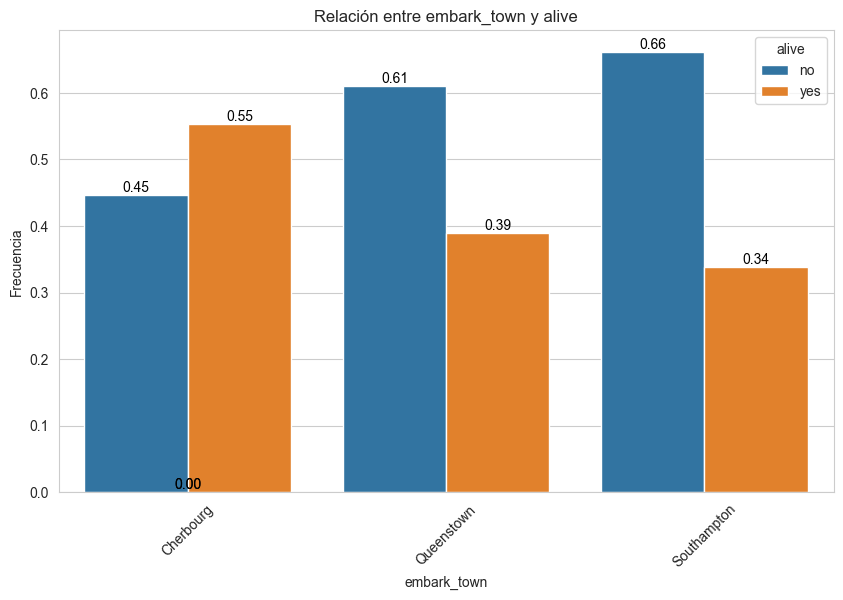

Chi-2 embark_town × alive: p=2.301e-06

Alone × alive (% por fila):
alive    no   yes
alone            
False  49.4  50.6
True   69.6  30.4
Chi-2 alone × alive: p=1.973e-09


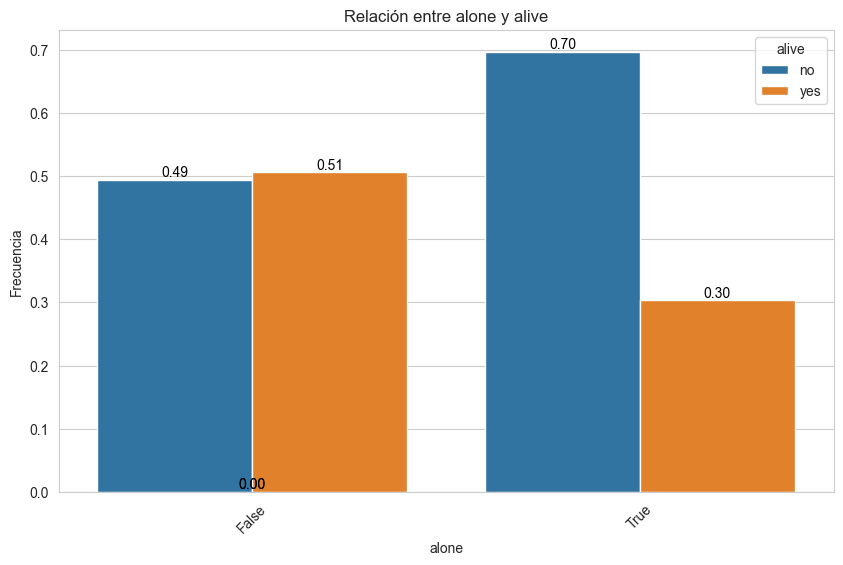

In [8]:
# === Preguntas 2, 3: clase, puerto de embarque y alone ===

# Clase
print("Clase \u00d7 alive (absolutos):")
print(pd.crosstab(df["class"], df["alive"], margins=True))
plot_categorical_relationship_fin(df, "class", "alive", relative_freq=True, show_values=True)
_, p_cl, _, _ = chi2_contingency(pd.crosstab(df["class"], df["alive"]))
print(f"Chi-2 class \u00d7 alive: p={p_cl:.4g}")

# Puerto de embarque
print("\nPuerto \u00d7 alive (absolutos):")
print(pd.crosstab(df["embark_town"], df["alive"], margins=True))
plot_categorical_relationship_fin(df, "embark_town", "alive", relative_freq=True, show_values=True)
_, p_em, _, _ = chi2_contingency(pd.crosstab(df["embark_town"], df["alive"]))
print(f"Chi-2 embark_town \u00d7 alive: p={p_em:.4g}")

# Alone: \u00bfviajar solo afecta a la supervivencia?
print("\nAlone \u00d7 alive (% por fila):")
tab_alone_rel = pd.crosstab(df["alone"], df["alive"], normalize="index").round(3) * 100
print(tab_alone_rel)
_, p_alone, _, _ = chi2_contingency(pd.crosstab(df["alone"], df["alive"]))
print(f"Chi-2 alone \u00d7 alive: p={p_alone:.4g}")
plot_categorical_relationship_fin(df, "alone", "alive", relative_freq=True, show_values=True)


En cifras absolutas sobrevivieron más de tercera clase, pero únicamente porque era la clase más numerosa. Si miro proporciones: primera clase ~63 %, segunda ~47 %, tercera ~24 %. El test lo confirma (p << 0.05), la relación es clara.

Con el puerto pasa algo parecido al principio: Southampton tiene más supervivientes en bruto simplemente por volumen. Cherbourg sale mejor en porcentaje, pero hay que mirar más fino (ver análisis estratificado a continuación) porque parte de eso puede ser efecto de la clase social, no del puerto en sí.

Lo de `alone` es interesante pero hay que tomarlo con cautela: viajar acompañado aparece asociado a más supervivencia, pero las mujeres —que sobrevivieron mucho más— tendían a viajar con familia. Es difícil saber si es `alone` lo que influye o simplemente es un subproducto del sexo.

In [9]:
# === Pregunta 3 (profundidad): puerto controlando por clase y por who ===

# Creamos variable numérica para facilitar la media de supervivencia
df["alive_num"] = (df["alive"] == "yes").astype(int)

print("Tasa de supervivencia (%) por puerto, desglosado por clase:")
tab_puerto_clase = (
    df.groupby(["embark_town", "class"])["alive_num"]
    .mean().mul(100).round(1)
    .unstack("class")
)
print(tab_puerto_clase)

print("\nTasa de supervivencia (%) por puerto, desglosado por who:")
tab_puerto_who = (
    df.groupby(["embark_town", "who"])["alive_num"]
    .mean().mul(100).round(1)
    .unstack("who")
)
print(tab_puerto_who)

# Distribución de clase por puerto (para ver si hay mix diferente)
print("\nDistribuci\u00f3n de clases por puerto (% por fila):")
print(
    pd.crosstab(df["embark_town"], df["class"], normalize="index")
    .mul(100).round(1)
)


Tasa de supervivencia (%) por puerto, desglosado por clase:
class        First  Second  Third
embark_town                      
Cherbourg     69.4    52.9   37.9
Queenstown    50.0    66.7   37.5
Southampton   58.9    46.3   19.0

Tasa de supervivencia (%) por puerto, desglosado por who:
who          child   man  woman
embark_town                    
Cherbourg     77.8  28.9   88.3
Queenstown    20.0   8.1   74.3
Southampton   56.7  14.4   71.6

Distribución de clases por puerto (% por fila):
class        First  Second  Third
embark_town                      
Cherbourg     50.6    10.1   39.3
Queenstown     2.6     3.9   93.5
Southampton   20.0    25.4   54.6


Al desglosar por clase, las diferencias entre puertos desaparecen casi del todo. Dentro de cada clase la tasa de supervivencia es bastante parecida entre Southampton, Cherbourg y Queenstown. Lo que distorsionaba la comparación global es que Cherbourg tenía proporcionalmente más primera clase. El puerto de embarque no explica la supervivencia por sí solo: es un reflejo de quién embarcó allí.

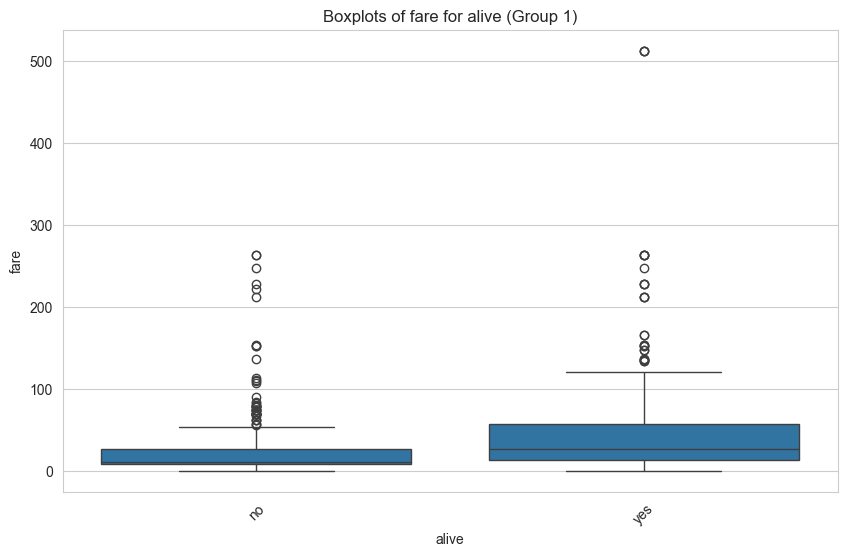

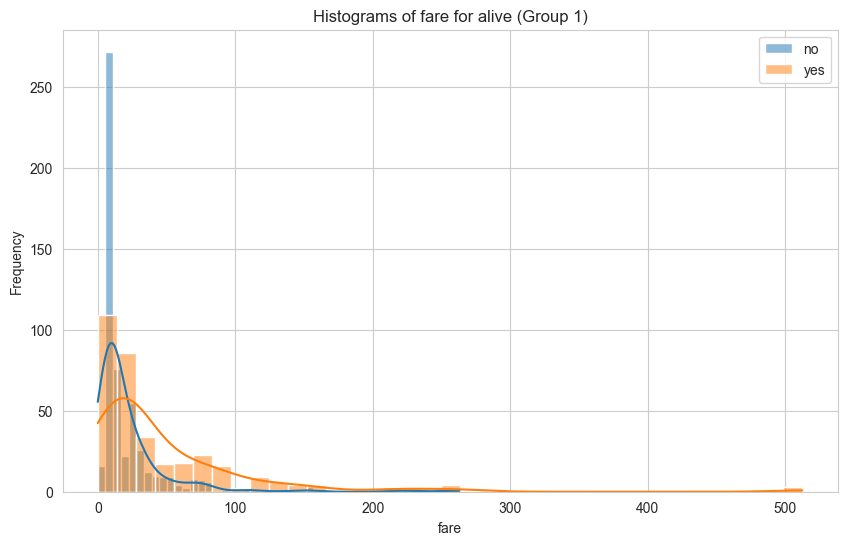

Mann-Whitney fare según alive: p=4.553e-22

Mediana de fare por supervivencia:
alive
no     10.5
yes    26.0
Name: fare, dtype: float64

Pasajeros con fare = 0: 15
      sex        age   class  fare  embark_town  who
179  male  36.000000   Third   0.0  Southampton  man
263  male  40.000000   First   0.0  Southampton  man
271  male  25.000000   Third   0.0  Southampton  man
277  male  33.173123  Second   0.0  Southampton  man
302  male  19.000000   Third   0.0  Southampton  man
413  male  33.173123  Second   0.0  Southampton  man
466  male  33.173123  Second   0.0  Southampton  man
481  male  33.173123  Second   0.0  Southampton  man
597  male  49.000000   Third   0.0  Southampton  man
633  male  33.173123   First   0.0  Southampton  man
674  male  33.173123  Second   0.0  Southampton  man
732  male  33.173123  Second   0.0  Southampton  man
806  male  39.000000   First   0.0  Southampton  man
815  male  33.173123   First   0.0  Southampton  man
822  male  38.000000   First   0.0  South

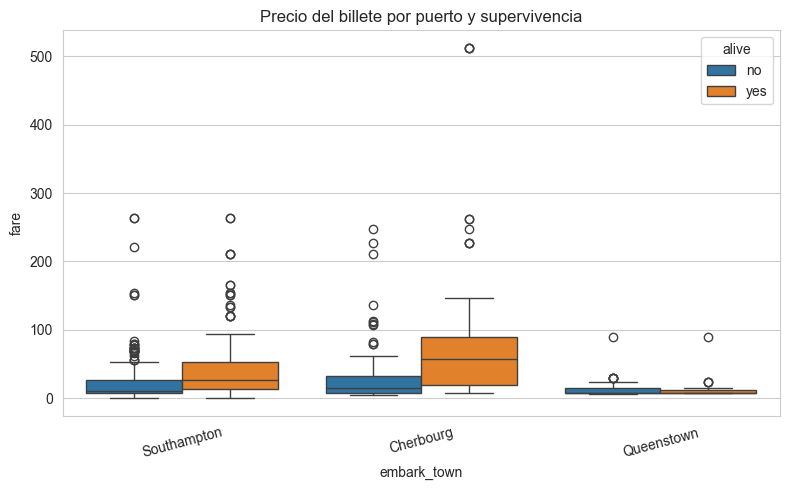

In [10]:
# === Preguntas 4, 5, 6: precio del billete y ciudad de embarque ===

# Pregunta 4: fare vs alive
plot_grouped_boxplots(df, "alive", "fare")
plot_grouped_histograms(df, "alive", "fare", group_size=2)
_, p_fare = mannwhitneyu(
    df.loc[df["alive"] == "yes", "fare"],
    df.loc[df["alive"] == "no", "fare"],
    alternative="two-sided",
)
print(f"Mann-Whitney fare seg\u00fan alive: p={p_fare:.4g}")
print("\nMediana de fare por supervivencia:")
print(df.groupby("alive")["fare"].median().round(2))

# Pregunta 5: fare == 0 y fare m\u00e1ximo
cero = df[df["fare"] <= 0]
print(f"\nPasajeros con fare = 0: {len(cero)}")
print(cero[["sex", "age", "class", "fare", "embark_town", "who"]].to_string())

print("\nPasajero con mayor fare:")
print(df.loc[df["fare"].idxmax()][["sex", "age", "class", "fare", "embark_town", "alive"]])

# Pregunta 6: fare \u00d7 embark_town \u00d7 alive (visual)
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="embark_town", y="fare", hue="alive", ax=ax)
ax.set_title("Precio del billete por puerto y supervivencia")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


Los supervivientes pagaron de mediana bastante más que los que no sobrevivieron, y Mann-Whitney confirma que la diferencia es significativa. Tiene sentido: tarifa alta suele implicar primera clase, y ya vimos que primera clase tenía mucha mejor tasa de supervivencia. El fare es casi un proxy de la clase.

Los que tienen fare = 0 parecen ser tripulación o personas que viajaban sin billete de pago. El pasajero que más pagó iba en primera desde Cherbourg y sobrevivió, coherente con todo lo anterior.

En el gráfico del punto 6 se ve bastante claro: Cherbourg concentra las tarifas altas y también los supervivientes. Southampton tiene más mezcla de todo.

In [11]:
# === Pregunta 7: clase \u00d7 edad (cuartiles) \u00d7 alive ===

df["edad_cat"] = pd.qcut(df["age"], q=4, duplicates="drop")

print("Clase \u00d7 tramo edad \u00d7 alive (absolutos):")
tab7 = pd.crosstab([df["class"], df["edad_cat"]], df["alive"])
print(tab7)

print("\n% de supervivencia por combinaci\u00f3n clase\u2013edad:")
prop7 = pd.crosstab([df["class"], df["edad_cat"]], df["alive"], normalize="index") * 100
print(prop7.round(1))


Clase × tramo edad × alive (absolutos):
alive                  no  yes
class  edad_cat               
First  (0.419, 22.0]    6   23
       (22.0, 32.0]    11   37
       (32.0, 35.0]    17   18
       (35.0, 80.0]    46   58
Second (0.419, 22.0]   12   29
       (22.0, 32.0]    38   28
       (32.0, 35.0]    16   11
       (35.0, 80.0]    31   19
Third  (0.419, 22.0]  115   46
       (22.0, 32.0]    98   56
       (32.0, 35.0]   102   11
       (35.0, 80.0]    57    6

% de supervivencia por combinación clase–edad:
alive                   no   yes
class  edad_cat                 
First  (0.419, 22.0]  20.7  79.3
       (22.0, 32.0]   22.9  77.1
       (32.0, 35.0]   48.6  51.4
       (35.0, 80.0]   44.2  55.8
Second (0.419, 22.0]  29.3  70.7
       (22.0, 32.0]   57.6  42.4
       (32.0, 35.0]   59.3  40.7
       (35.0, 80.0]   62.0  38.0
Third  (0.419, 22.0]  71.4  28.6
       (22.0, 32.0]   63.6  36.4
       (32.0, 35.0]   90.3   9.7
       (35.0, 80.0]   90.5   9.5


En absoluto gana primera clase adulta media simplemente porque hay más pasajeros ahí. En relativo, primera clase está por encima en todos los tramos de edad, y tercera clase tiene tasas bajas independientemente de la edad. Los niños de primera tienen una tasa altísima pero son muy pocos casos, así que hay que interpretarlo con cuidado. En general la clase pesa más que la edad.

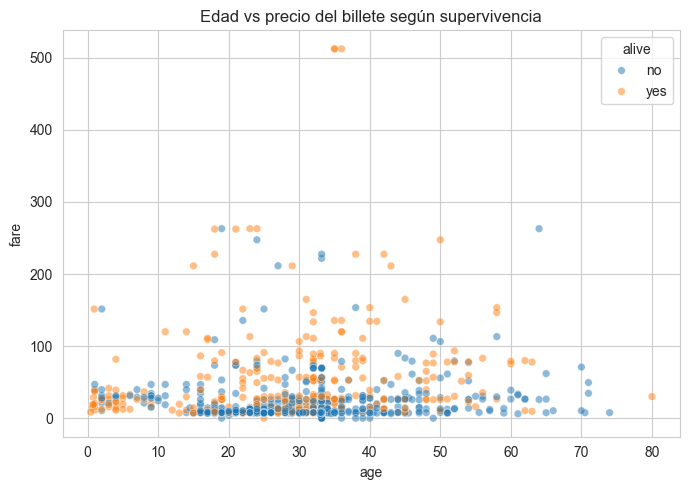

Pearson age–fare (todos): r=0.081, p=0.01589

Mediana de fare por tipo de edad y supervivencia:
tipo_edad  alive
adulto     no        9.50
           yes      26.25
niño       no       29.12
           yes      20.52
Name: fare, dtype: float64


In [12]:
# === Pregunta 8: edad, coste del billete y supervivencia ===

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=df, x="age", y="fare", hue="alive", alpha=0.5, s=30, ax=ax)
ax.set_title("Edad vs precio del billete seg\u00fan supervivencia")
plt.tight_layout()
plt.show()

r_all, p_all = pearsonr(df["age"], df["fare"])
print(f"Pearson age\u2013fare (todos): r={r_all:.3f}, p={p_all:.4g}")
print("\nMediana de fare por tipo de edad y supervivencia:")
print(df.groupby(["tipo_edad", "alive"])["fare"].median().round(2))


La correlación entre edad y fare es baja, o sea la edad por sí sola no explica el precio del billete. En el scatter se ve que los puntos con `alive = yes` tienden a estar en la parte de arriba (fares altos) a lo largo de todo el rango de edades, lo que vuelve a apuntar al fare como el factor que discrimina. La edad no cambia sustancialmente ese patrón.

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

Vuelos por compañía:
aircompany
TabarAir      142
MoldaviAir    133
PamPangea     117
FlyQ          108
Airnar        100
Name: count, dtype: int64


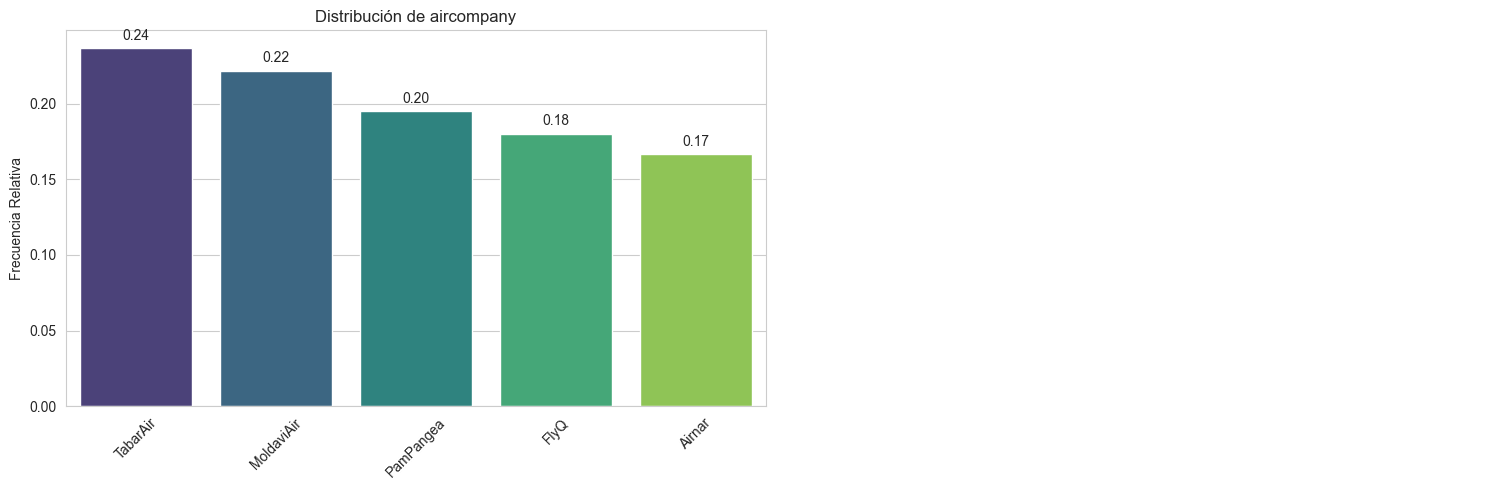

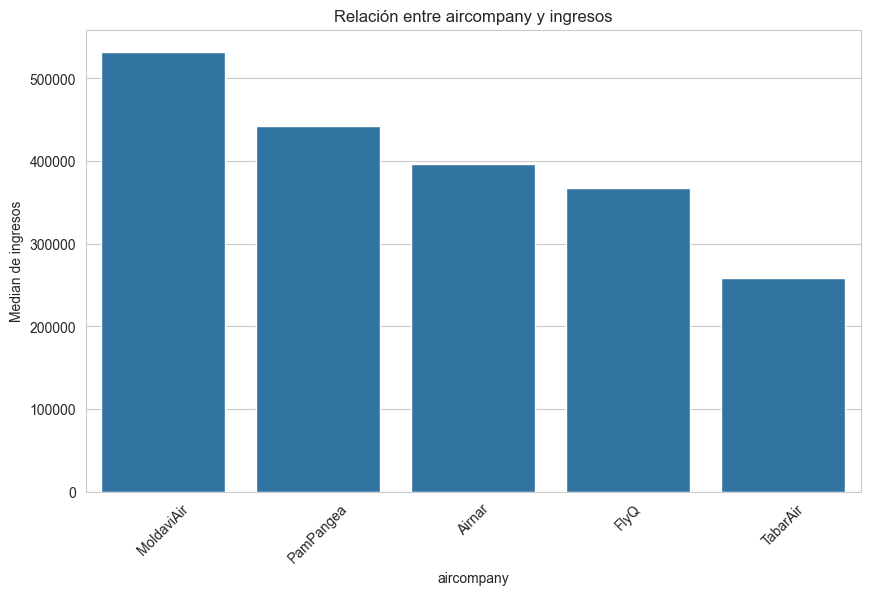

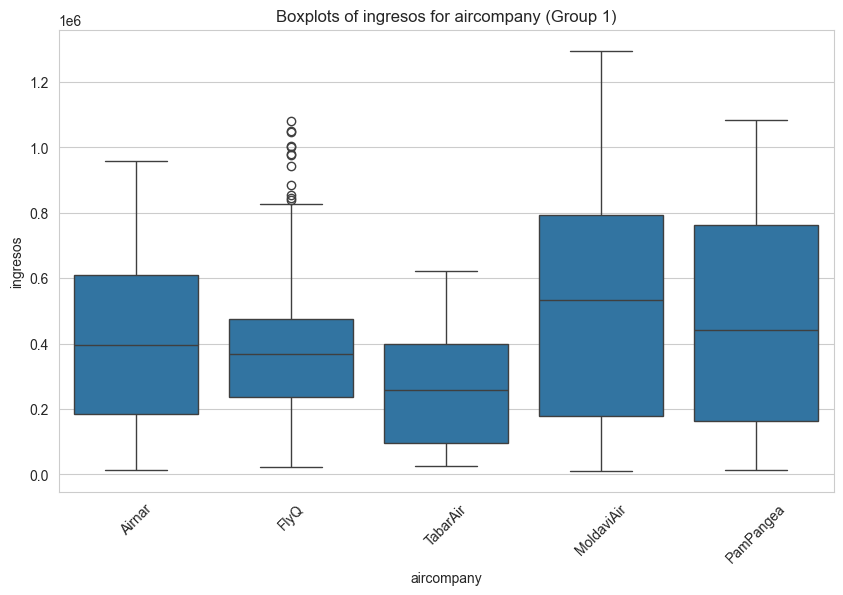


Resumen por compañía (ordenado por mediana de ingreso):
            n_vuelos  ingreso_total  ingreso_por_vuelo  mediana_ingreso
aircompany                                                             
TabarAir         142     38487997.0          271042.23        258379.74
FlyQ             108     43374853.0          401619.01        366970.68
Airnar           100     40529398.0          405293.98        396764.22
PamPangea        117     55974795.0          478417.05        442668.52
MoldaviAir       133     72894269.0          548077.21        532426.22


In [13]:
viajes = pd.read_csv("./data/dataset_viajes_jun.csv")
print("Vuelos por compa\u00f1\u00eda:")
print(viajes["aircompany"].value_counts())

pinta_distribucion_categoricas(viajes, ["aircompany"], relativa=True, mostrar_valores=True)
plot_categorical_numerical_relationship(viajes, "aircompany", "ingresos", measure="median")
plot_grouped_boxplots(viajes, "aircompany", "ingresos")

# Tabla resumen: volumen y rentabilidad por compa\u00f1\u00eda
resumen = viajes.groupby("aircompany").agg(
    n_vuelos=("ingresos", "count"),
    ingreso_total=("ingresos", "sum"),
    ingreso_por_vuelo=("ingresos", "mean"),
    mediana_ingreso=("ingresos", "median"),
)
resumen["ingreso_total"] = resumen["ingreso_total"].round(0)
resumen["ingreso_por_vuelo"] = resumen["ingreso_por_vuelo"].round(2)
resumen["mediana_ingreso"] = resumen["mediana_ingreso"].round(2)
resumen = resumen.sort_values("mediana_ingreso")
print("\nResumen por compa\u00f1\u00eda (ordenado por mediana de ingreso):")
print(resumen)


TabarAir hace la gran mayoría de los vuelos, con lo cual en ingreso total es la que más suma, por puro volumen. El problema aparece cuando miro el ingreso por vuelo: tanto la mediana como la media de TabarAir están por debajo de las otras compañías. Volamos más pero generamos menos por operación, lo que sugiere que nuestra cartera de rutas no es la más eficiente. Las otras aerolíneas tienen muestras muy pequeñas, así que con ellas hay que ir con cuidado, pero la tendencia vale la pena mirarla.

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

Pearson distancia–consumo_kg: r=0.762, p=4.185e-115


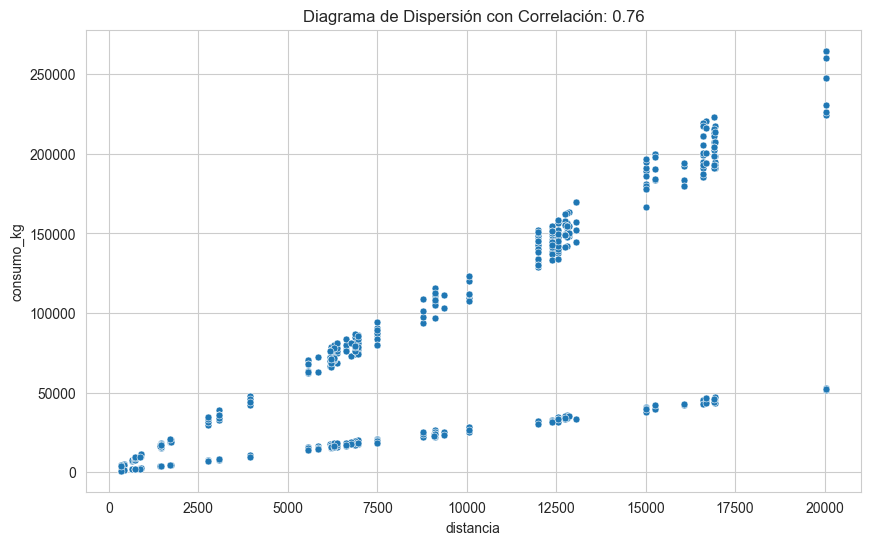

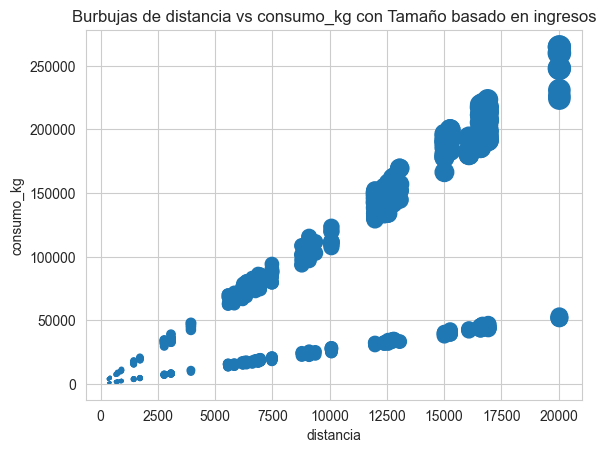

In [14]:
# Correlaci\u00f3n distancia\u2013consumo y relaci\u00f3n con ingresos
r_dist, p_dist = pearsonr(viajes["distancia"], viajes["consumo_kg"])
print(f"Pearson distancia\u2013consumo_kg: r={r_dist:.3f}, p={p_dist:.4g}")

grafico_dispersion_con_correlacion(
    viajes, "distancia", "consumo_kg", tamano_puntos=25, mostrar_correlacion=True
)
bubble_plot(viajes, "distancia", "consumo_kg", "ingresos", scale=5000)


Distancia y consumo correlacionan fuerte y en positivo, nada sorprendente. Lo que sí llama la atención en el bubble plot es que para niveles de consumo similares hay vuelos con ingresos muy distintos. Eso significa que no todas las rutas son igual de rentables aunque gasten lo mismo en combustible. Puede ser por la carga, el tipo de avión, la ruta específica... la distancia sola no lo explica.

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

Distribución de vuelos por tramo de distancia:
cat_vuelo
(343.999, 3073.0]     170
(3073.0, 6877.0]      131
(6877.0, 12553.0]     157
(12553.0, 20029.0]    142
Name: count, dtype: int64

Resumen por tramo (con ratio ingreso/consumo):
                    n_vuelos  ingreso_medio  consumo_medio_kg  ratio_ing_cons
cat_vuelo                                                                    
(343.999, 3073.0]        170       69372.75          10325.61           6.719
(3073.0, 6877.0]         131      305331.33          44962.79           6.791
(6877.0, 12553.0]        157      524261.03          84527.93           6.202
(12553.0, 20029.0]       142      825074.34         141041.89           5.850


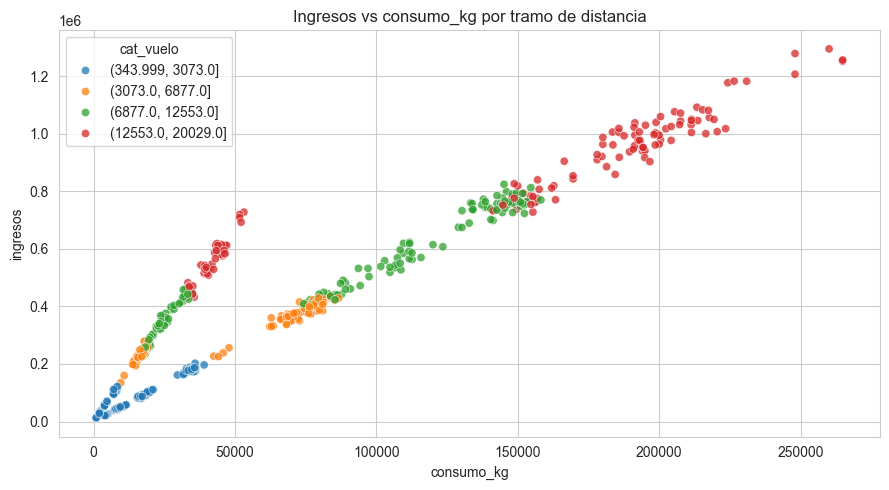

In [15]:
viajes["cat_vuelo"] = pd.qcut(viajes["distancia"], q=4, duplicates="drop")
print("Distribuci\u00f3n de vuelos por tramo de distancia:")
print(viajes["cat_vuelo"].value_counts().sort_index())

resumen_tramo = viajes.groupby("cat_vuelo", observed=True).agg(
    n_vuelos=("ingresos", "count"),
    ingreso_medio=("ingresos", "mean"),
    consumo_medio_kg=("consumo_kg", "mean"),
).round(2)
resumen_tramo["ratio_ing_cons"] = (
    resumen_tramo["ingreso_medio"] / resumen_tramo["consumo_medio_kg"]
).round(3)
print("\nResumen por tramo (con ratio ingreso/consumo):")
print(resumen_tramo)

fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=viajes,
    x="consumo_kg",
    y="ingresos",
    hue="cat_vuelo",
    alpha=0.75,
    ax=ax,
)
ax.set_title("Ingresos vs consumo_kg por tramo de distancia")
plt.tight_layout()
plt.show()


Segmentar por tramo le da algo más de forma a la nube del gráfico anterior: cada grupo queda más o menos en su zona. El ratio ingreso/consumo de la tabla es lo más útil: si varía entre tramos hay tramos de distancia más rentables que otros, y eso ya es algo sobre lo que actuar. La variabilidad que queda dentro de cada tramo seguramente viene de variables que no estamos viendo (ruta específica, temporada, tipo de aeronave...).

## Conclusiones

En el Titanic, lo que más explica la supervivencia es la clase y el sexo. El chi-cuadrado lo deja claro en los dos casos. La tarifa es prácticamente lo mismo que la clase (pagar más = viajar mejor = más opciones de sobrevivir), así que los tres van de la mano. El puerto aparece con diferencias a nivel global, pero al controlar por clase esas diferencias se reducen bastante: Cherbourg tenía más primera clase, no era el puerto lo que salvaba. Hay que tener cuidado con los subgrupos pequeños (niños de primera, pasajeros con fare = 0) porque las estimaciones son poco fiables.

Con los viajes, lo llamativo es que TabarAir tiene el peor rendimiento por vuelo pese a operar la mayoría. Segmentar por distancia ayuda a ver que hay grupos de rutas con dinámicas distintas, y el ratio ingreso/consumo es el dato más útil para ver cuáles merecen la pena. Lo que queda por entender es la variabilidad dentro de cada tramo, que necesitaría variables adicionales.